# Transfer learning in image classification

# In this notebook we will use transfer learning and take pre-trained model from google's Tensorflow Hub and re-train that on flowers dataset. Using pre-trained model saves lot of time and computational budget for new classification problem at hand

# Importing Dependencies and Library

In [3]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential



# Make predictions using ready made model (without any training)

In [4]:
# Reinstall TensorFlow with a stable version (2.19.0) and compatible tensorflow-hub
!pip install tensorflow==2.19.0 tensorflow-hub==0.16.1

In [5]:
import tensorflow as tf

classifier = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=True,
    weights="imagenet"
)

In [6]:
import numpy as np
import cv2
import PIL.Image as Image
import matplotlib.pylab as plt
import tensorflow as tf

IMAGE_SHAPE = (224, 224)

classifier = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=True,
    weights="imagenet"
)

In [7]:
import tensorflow as tf
import numpy as np

# Download ImageNet labels
labels_path = tf.keras.utils.get_file(
    "ImageNetLabels.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt"
)

# Read labels into a list
with open(labels_path, "r") as f:
    imagenet_labels = f.read().splitlines()

print("Number of labels:", len(imagenet_labels))
print(imagenet_labels[:5])

Number of labels: 1001
['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']


In [8]:
print(labels_path)

/root/.keras/datasets/ImageNetLabels.txt


In [9]:
with open(labels_path, "r") as f:
    imagenet_labels = f.read().splitlines()

print(imagenet_labels[:50])

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon']


In [10]:
import requests
from PIL import Image
import matplotlib.pyplot as plt

image_url = "https://cafishvet.com/wp-content/uploads/2021/05/Gold-Fish-.jpeg"
save_path = "/content/goldfish.jpeg"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(image_url, headers=headers)
response.raise_for_status()

with open(save_path, "wb") as f:
    f.write(response.content)

print("Saved at:", save_path)

img = Image.open(save_path)


Saved at: /content/goldfish.jpeg


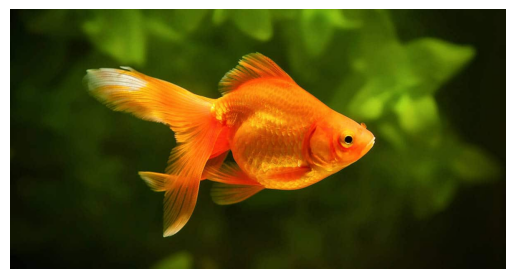

In [11]:
plt.imshow(img)
plt.axis("off")
plt.show()

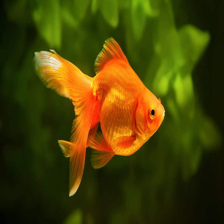

In [12]:
gold_fish = Image.open("goldfish.jpeg").resize(IMAGE_SHAPE)
gold_fish

In [13]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [14]:
gold_fish[np.newaxis, ...]

array([[[[0.02352941, 0.03529412, 0.        ],
         [0.03137255, 0.04313725, 0.00784314],
         [0.03529412, 0.04705882, 0.01176471],
         ...,
         [0.0745098 , 0.08627451, 0.01176471],
         [0.0745098 , 0.08627451, 0.01176471],
         [0.0745098 , 0.08627451, 0.01176471]],

        [[0.02352941, 0.03529412, 0.        ],
         [0.02745098, 0.03921569, 0.00784314],
         [0.03529412, 0.04705882, 0.01176471],
         ...,
         [0.0745098 , 0.08627451, 0.01176471],
         [0.0745098 , 0.08627451, 0.01176471],
         [0.0745098 , 0.08627451, 0.01176471]],

        [[0.02352941, 0.03529412, 0.        ],
         [0.02745098, 0.03921569, 0.00784314],
         [0.03529412, 0.04705882, 0.01176471],
         ...,
         [0.0745098 , 0.08627451, 0.01176471],
         [0.0745098 , 0.08627451, 0.01176471],
         [0.0745098 , 0.08627451, 0.01176471]],

        ...,

        [[0.01568627, 0.01568627, 0.00784314],
         [0.01568627, 0.01568627, 0.00784314]

In [17]:
result = classifier.predict(gold_fish[np.newaxis, ...])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [16]:
result.shape

(1, 1000)

In [18]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(1)

In [23]:
# tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
image_labels = []
with open(labels_path, "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [22]:
image_labels[predicted_label_index]

'tench'